In [1]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

Train data

In [2]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage Pb')

In [3]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb2-4-0.jpg,0.515198,7.313342,14.283245,1.801760
1,rl1_pb2-4-1.jpg,0.583197,7.098072,14.095450,1.866517
2,rl1_pb2-4-10.jpg,0.510283,7.041337,14.173860,1.804548
3,rl1_pb2-4-11.jpg,0.548026,7.199120,14.914973,1.912376
4,rl1_pb2-4-12.jpg,0.595924,7.325093,14.182048,1.836217
...,...,...,...,...,...
1553,rl4_pb8-7-59.jpg,0.518576,10.253074,50.915752,3.865610
1554,rl4_pb8-7-6.jpg,0.473020,9.847562,51.117869,3.730934
1555,rl4_pb8-7-7.jpg,0.451352,9.980971,51.787354,3.746070
1556,rl4_pb8-7-8.jpg,0.562965,10.049803,50.655126,3.797525


In [4]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [5]:
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])

In [6]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [7]:
fft_features.shape

(1558, 400)

In [8]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((1558,), (1558,), (1558,), (1558,))

In [9]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [10]:
labels.shape

(1558, 4)

SVM with FFT and PCA

In [11]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

Linear Regression with FFT and PCA

In [12]:
lr = LinearRegression()
mlr = MultiOutputRegressor(lr)
mlr.fit(fft_features, labels)

MultiOutputRegressor(estimator=LinearRegression())

XGBoost with FFT and PCA

In [13]:
xgb = XGBRegressor()
mxgb = MultiOutputRegressor(xgb)
mxgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...))

Catboost with FFT and PCA

In [14]:
cbr = cb.CatBoostRegressor()
mcb = MultiOutputRegressor(cbr)
mcb.fit(fft_features, labels, verbose=False)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x0000020DF5101BB0>)

Random Forest with FFT and PCA

In [15]:
rf = RandomForestRegressor()
mrf = MultiOutputRegressor(rf)
mrf.fit(fft_features, labels)

MultiOutputRegressor(estimator=RandomForestRegressor())

Gradient Boosting with FFT and PCA

In [16]:
gb = GradientBoostingRegressor()
mgb = MultiOutputRegressor(gb)
mgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=GradientBoostingRegressor())

Ada Boost with FFT and PCA

In [17]:
ada = AdaBoostRegressor()
mada = MultiOutputRegressor(ada)
mada.fit(fft_features, labels)

MultiOutputRegressor(estimator=AdaBoostRegressor())

Decision Trees with FFT and PCA

In [18]:
dt = DecisionTreeRegressor()
mdt = MultiOutputRegressor(dt)
mdt.fit(fft_features, labels)

MultiOutputRegressor(estimator=DecisionTreeRegressor())

KNN with FFT and PCA

In [19]:
knn = KNeighborsRegressor()
mknn = MultiOutputRegressor(knn)
mknn.fit(fft_features, labels)

MultiOutputRegressor(estimator=KNeighborsRegressor())

test data

In [20]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage Pb')

In [21]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl3_pb2-4-0.jpg,0.249555,4.373331,25.436357,1.222832
1,rl3_pb2-4-1.jpg,0.347140,4.384538,25.835127,1.191096
2,rl3_pb2-4-10.jpg,0.350744,4.295009,25.630555,1.164672
3,rl3_pb2-4-11.jpg,0.352308,4.035775,25.948042,1.137446
4,rl3_pb2-4-12.jpg,0.292288,4.203754,24.947959,1.158895
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,1.852368,6.018676,58.016706,1.346629
386,rl4_pb30-6-61.jpg,1.785060,5.918743,58.953459,1.289768
387,rl4_pb30-6-7.jpg,1.894811,6.240627,59.092005,1.363355
388,rl4_pb30-6-8.jpg,1.842435,6.078825,58.178368,1.264773


In [22]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [23]:
for line in df_test.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_cu.append(line[1])
    test_labels_fe.append(line[2])
    test_labels_pb.append(line[3])
    test_labels_zn.append(line[4])

In [24]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [25]:
test_fft_features.shape

(390, 400)

In [26]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [27]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [28]:
test_labels.shape

(390, 4)

SVM

In [29]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.4361563743758134
MSE 68.10634762502612
R2 Score 0.017991103251464635


In [30]:
# pickle.dump(msvm, open("./models/svm_model", 'wb'))

XGBoost

In [31]:
y_pred = mxgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.653307364363432
MSE 56.995591611823066
R2 Score 0.09508229840537474


In [32]:
# pickle.dump(mxgb, open("./models/xgboost_model", 'wb'))

Linear Regression

In [33]:
y_pred = mlr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.826571093210146
MSE 61.07868433580226
R2 Score 0.04993590569134068


In [34]:
# pickle.dump(mlr, open("./models/linear_regression_model", 'wb'))

Catboost

In [35]:
y_pred = mcb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.439163571561761
MSE 48.83921796306152
R2 Score 0.17461070621153144


In [36]:
# pickle.dump(mcb, open("./models/catboost_model", 'wb'))

Random Forest

In [37]:
y_pred = mrf.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.480182531942973
MSE 46.88695725926123
R2 Score 0.17921657444653108


In [38]:
# pickle.dump(mrf, open("./models/random_forest_model", 'wb'))

Grandient Boosting

In [39]:
y_pred = mgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.510530213330955
MSE 49.90337487200021
R2 Score 0.17232121781019466


In [40]:
# pickle.dump(mgb, open("./models/gradient_boosting_model", 'wb'))

Ada Boosting

In [41]:
y_pred = mada.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.644933647686861
MSE 46.51761511204198
R2 Score 0.15329265859555888


In [42]:
# pickle.dump(mada, open("./models/ada_boosting_model", 'wb'))

Decision Trees

In [43]:
y_pred = mdt.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.590906516001059
MSE 94.44384630278356
R2 Score -0.3018997241799106


In [44]:
# pickle.dump(mdt, open("./models/decision_tree_model", 'wb'))

KNN

In [45]:
y_pred = mknn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.1089381588687175
MSE 44.71589920041949
R2 Score 0.227620933403487


In [46]:
# pickle.dump(mknn, open("./models/knn_model", 'wb'))

# All test videos average

In [47]:
test_videos = ["rl4_pb12-4.mp4", "rl1_pb16-4.mp4", "rl3_pb23-4.mp4", "rl1_pb9-5.mp4", "rl4_pb30-6.mp4"]
models = [msvm, mrf, mxgb, mcb, mgb, mada, mdt, mknn]

In [48]:
final_results_df = pd.DataFrame(columns=["Model", "Cu", "Fe", "Pb", "Zn"])

In [49]:
for model in models:
    model_name = type(model.estimator).__name__
    avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
    for test_vid in test_videos:
        TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
        Teneur_predit = predict_video("../video_test/" + test_vid, model)
        Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
        avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
        avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
        avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
        avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
        print(model_name + " " + test_vid + " done")
    avgs_cu = np.mean(avgs_cu)
    avgs_fe = np.mean(avgs_fe)
    avgs_pb = np.mean(avgs_pb)
    avgs_zn = np.mean(avgs_zn)
    final_results_df = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

SVR rl4_pb12-4.mp4 done
SVR rl1_pb16-4.mp4 done
SVR rl3_pb23-4.mp4 done
SVR rl1_pb9-5.mp4 done
SVR rl4_pb30-6.mp4 done
RandomForestRegressor rl4_pb12-4.mp4 done
RandomForestRegressor rl1_pb16-4.mp4 done
RandomForestRegressor rl3_pb23-4.mp4 done
RandomForestRegressor rl1_pb9-5.mp4 done
RandomForestRegressor rl4_pb30-6.mp4 done
XGBRegressor rl4_pb12-4.mp4 done
XGBRegressor rl1_pb16-4.mp4 done
XGBRegressor rl3_pb23-4.mp4 done
XGBRegressor rl1_pb9-5.mp4 done
XGBRegressor rl4_pb30-6.mp4 done
CatBoostRegressor rl4_pb12-4.mp4 done
CatBoostRegressor rl1_pb16-4.mp4 done
CatBoostRegressor rl3_pb23-4.mp4 done
CatBoostRegressor rl1_pb9-5.mp4 done
CatBoostRegressor rl4_pb30-6.mp4 done
GradientBoostingRegressor rl4_pb12-4.mp4 done
GradientBoostingRegressor rl1_pb16-4.mp4 done
GradientBoostingRegressor rl3_pb23-4.mp4 done
GradientBoostingRegressor rl1_pb9-5.mp4 done
GradientBoostingRegressor rl4_pb30-6.mp4 done
AdaBoostRegressor rl4_pb12-4.mp4 done
AdaBoostRegressor rl1_pb16-4.mp4 done
AdaBoostRegres

In [50]:
final_results_df

,Model,Cu,Fe,Pb,Zn
0,SVR,1.194777,4.230588,13.488675,1.591189
1,RandomForestRegressor,1.055594,3.474981,9.875717,1.763085
2,XGBRegressor,1.034295,3.708158,9.521421,1.753708
3,CatBoostRegressor,1.015002,3.302458,9.610463,1.686577
4,GradientBoostingRegressor,1.037435,3.333922,9.657180,1.647563
5,AdaBoostRegressor,1.033845,4.067082,10.435542,1.954829
6,DecisionTreeRegressor,1.095821,2.798363,11.060878,1.682006
7,KNeighborsRegressor,1.010921,3.210087,7.608464,1.614313


In [51]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [52]:
nn = Sequential()
nn.add(Dense(400, activation='relu', input_shape=(fft_features.shape[1],)))
nn.add(Dropout(0.2))
nn.add(Dense(200, activation='relu'))
nn.add(Dropout(0.2))
nn.add(Dense(50, activation='relu'))
nn.add(Dense(4, activation='linear'))

opt = Adam(learning_rate=0.0001)
nn.compile(optimizer=opt, metrics=['mae'], loss='mse')

In [53]:
hist = nn.fit(fft_features, labels, epochs=200, batch_size=16, verbose=1)

Epoch 1/200
98/98 [==============================] - 1s 3ms/step - loss: 203.0353 - mae: 9.5517
Epoch 2/200
98/98 [==============================] - 0s 3ms/step - loss: 97.2601 - mae: 6.8387
Epoch 3/200
98/98 [==============================] - 0s 3ms/step - loss: 89.4612 - mae: 6.2969
Epoch 4/200
98/98 [==============================] - 0s 3ms/step - loss: 84.3543 - mae: 5.9777
Epoch 5/200
98/98 [==============================] - 0s 3ms/step - loss: 78.2545 - mae: 5.7317
Epoch 6/200
98/98 [==============================] - 0s 3ms/step - loss: 77.1743 - mae: 5.6493
Epoch 7/200
98/98 [==============================] - 0s 3ms/step - loss: 73.1050 - mae: 5.4526
Epoch 8/200
98/98 [==============================] - 0s 3ms/step - loss: 67.8850 - mae: 5.2493
Epoch 9/200
98/98 [==============================] - 0s 3ms/step - loss: 69.2473 - mae: 5.1905
Epoch 10/200
98/98 [==============================] - 0s 3ms/step - loss: 66.0562 - mae: 5.1029
Epoch 11/200
98/98 [============================

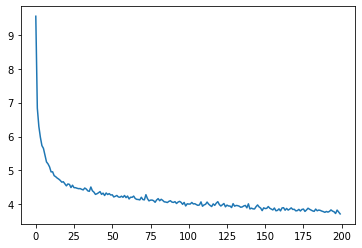

In [54]:
plt.plot(hist.history['mae'])
plt.show()

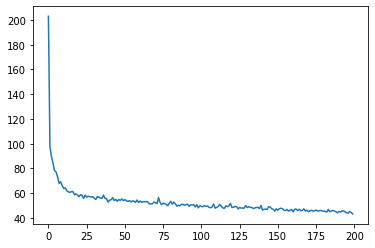

In [55]:
plt.plot(hist.history['loss'])
plt.show()

In [56]:
y_pred = nn.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 5.101139011784754
MSE 64.29557375426366
R2 Score -0.11786115776645845


In [57]:
model_name = "Neural Network"
avgs_cu, avgs_fe, avgs_pb, avgs_zn = [], [], [], []
for test_vid in test_videos:
    TeunneurReel = TenneurReel(test_vid, "DataSource.xlsx")
    Teneur_predit = predict_video("../video_test/" + test_vid, nn)
    Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
    avgs_cu.append(abs(TeunneurReel[0] - Moyenne[0]))
    avgs_fe.append(abs(TeunneurReel[1] - Moyenne[1]))
    avgs_pb.append(abs(TeunneurReel[2] - Moyenne[2]))
    avgs_zn.append(abs(TeunneurReel[3] - Moyenne[3]))
    print(model_name + " " + test_vid + " done")
avgs_cu = np.mean(avgs_cu)
avgs_fe = np.mean(avgs_fe)
avgs_pb = np.mean(avgs_pb)
avgs_zn = np.mean(avgs_zn)
t = pd.concat([final_results_df, pd.DataFrame({"Model": model_name, "Cu": avgs_cu, "Fe": avgs_fe, "Pb": avgs_pb, "Zn": avgs_zn}, index=[0])], ignore_index=True)

Neural Network rl4_pb12-4.mp4 done
Neural Network rl1_pb16-4.mp4 done
Neural Network rl3_pb23-4.mp4 done
Neural Network rl1_pb9-5.mp4 done
Neural Network rl4_pb30-6.mp4 done


In [58]:
t

,Model,Cu,Fe,Pb,Zn
0,SVR,1.194777,4.230588,13.488675,1.591189
1,RandomForestRegressor,1.055594,3.474981,9.875717,1.763085
2,XGBRegressor,1.034295,3.708158,9.521421,1.753708
3,CatBoostRegressor,1.015002,3.302458,9.610463,1.686577
4,GradientBoostingRegressor,1.037435,3.333922,9.657180,1.647563
5,AdaBoostRegressor,1.033845,4.067082,10.435542,1.954829
6,DecisionTreeRegressor,1.095821,2.798363,11.060878,1.682006
7,KNeighborsRegressor,1.010921,3.210087,7.608464,1.614313
8,Neural Network,1.306839,3.923939,10.210260,2.259537


In [59]:
mae_mse_df = pd.DataFrame(columns=["Model", "MAE", "MSE"])
for model in models:
    model_name = type(model.estimator).__name__
    y_pred = model.predict(test_fft_features)
    mae_mse_df = pd.concat([mae_mse_df, pd.DataFrame({"Model": model_name, "MAE": mean_absolute_error(test_labels, y_pred), "MSE": mean_squared_error(test_labels, y_pred)}, index=[0])], ignore_index=True)

In [60]:
mae_mse_df

,Model,MAE,MSE
0,SVR,5.436156,68.106348
1,RandomForestRegressor,4.480183,46.886957
2,XGBRegressor,4.653307,56.995592
3,CatBoostRegressor,4.439164,48.839218
4,GradientBoostingRegressor,4.510530,49.903375
5,AdaBoostRegressor,4.644934,46.517615
6,DecisionTreeRegressor,5.590907,94.443846
7,KNeighborsRegressor,4.108938,44.715899


In [61]:
model_name = "Neural Network"
y_pred = nn.predict(test_fft_features)
mae_mse_df = pd.concat([mae_mse_df, pd.DataFrame({"Model": model_name, "MAE": mean_absolute_error(test_labels, y_pred), "MSE": mean_squared_error(test_labels, y_pred)}, index=[0])], ignore_index=True)

In [65]:
mae_mse_df

,Model,MAE,MSE
0,SVR,5.436156,68.106348
1,RandomForestRegressor,4.480183,46.886957
2,XGBRegressor,4.653307,56.995592
3,CatBoostRegressor,4.439164,48.839218
4,GradientBoostingRegressor,4.510530,49.903375
5,AdaBoostRegressor,4.644934,46.517615
6,DecisionTreeRegressor,5.590907,94.443846
7,KNeighborsRegressor,4.108938,44.715899
8,Neural Network,5.101139,64.295574


In [67]:
# join t and mae_mse_df
final_results_df = pd.merge(t, mae_mse_df, on="Model")
final_results_df

,Model,Cu,Fe,Pb,Zn,MAE,MSE
0,SVR,1.194777,4.230588,13.488675,1.591189,5.436156,68.106348
1,RandomForestRegressor,1.055594,3.474981,9.875717,1.763085,4.480183,46.886957
2,XGBRegressor,1.034295,3.708158,9.521421,1.753708,4.653307,56.995592
3,CatBoostRegressor,1.015002,3.302458,9.610463,1.686577,4.439164,48.839218
4,GradientBoostingRegressor,1.037435,3.333922,9.657180,1.647563,4.510530,49.903375
5,AdaBoostRegressor,1.033845,4.067082,10.435542,1.954829,4.644934,46.517615
6,DecisionTreeRegressor,1.095821,2.798363,11.060878,1.682006,5.590907,94.443846
7,KNeighborsRegressor,1.010921,3.210087,7.608464,1.614313,4.108938,44.715899
8,Neural Network,1.306839,3.923939,10.210260,2.259537,5.101139,64.295574


In [68]:
final_results_df.to_excel("final_results_std.xlsx", index=False)